In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import tifffile as tiff

In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../src')

In [ ]:
img_name = 'HAND1_Brachyury_mid_+'
channel_names = ['HAND1', 'BMP4', 'T', 'Hoechst']

cell_df = pd.read_csv(f'../data/training/{img_name}.csv', index_col=0)
out = tiff.imread(f'../data/stitched/{img_name}.tif')
print(cell_df.shape, out.shape)

# Load the label mask and build the boolean cell mask
from tools.morphology import cells_mask_from_labels
label_mask = np.load(f'../data/stitched/{img_name}.tif.npy')
cell_mask = cells_mask_from_labels(label_mask, cell_df.index)
print("cell_mask shape:", cell_mask.shape)

## Extending the extrinsic question: pixels and spatial context directly

`intrinsic.ipynb` asks whether a cell's own morphology and its own immunofluorescence
travel together; `extrinsic.ipynb` asks the same thing using a cell's *neighbors'*
features instead of its own. This notebook pushes on the extrinsic side from two more
angles:

1. **Pixel level**: given one or more fluorescence channel *images*, can a model predict
   another channel's image directly, with no cell segmentation involved at all?
2. **Placement, explicitly combined with morphology**: given a cell's own shape *and*
   its spatial position/neighbors, predict its immunofluorescence (and vice versa) --
   the same mapping as `intrinsic.ipynb`, but now letting the model use graph/spatial
   structure that `intrinsic.ipynb` deliberately leaves out.

Both need many independent samples, and a single stitched mosaic is one sample. So
the image gets tiled into a grid of non-overlapping patches -- each patch becomes one
training example for both tasks below. Because patches never overlap and every
patch's k-NN graph only ever connects cells within that same patch, a plain
per-patch train/val/test split is already a genuine **spatially-blocked** split:
held-out patches share no pixels, cells, or graph edges with training patches. That's
a stronger generalization test than `intrinsic.ipynb`/`extrinsic.ipynb`'s random
per-cell split within one contiguous tissue.

In [ ]:
from tools.morphology import make_patch_grid, split_patches, crop_cell_df, set_seed

SEED = 0
PATCH_SIZE = 256  # shared by both tasks below, so results are directly comparable

set_seed(SEED)
patches = make_patch_grid(out.shape[1:], patch_size=PATCH_SIZE)
patch_split = split_patches(patches, val_frac=0.15, test_frac=0.15, seed=SEED)

train_patches = [p for p, s in zip(patches, patch_split) if s == 'train']
val_patches   = [p for p, s in zip(patches, patch_split) if s == 'val']
test_patches  = [p for p, s in zip(patches, patch_split) if s == 'test']
print(f'{len(patches)} patches total: {len(train_patches)} train, {len(val_patches)} val, {len(test_patches)} test')

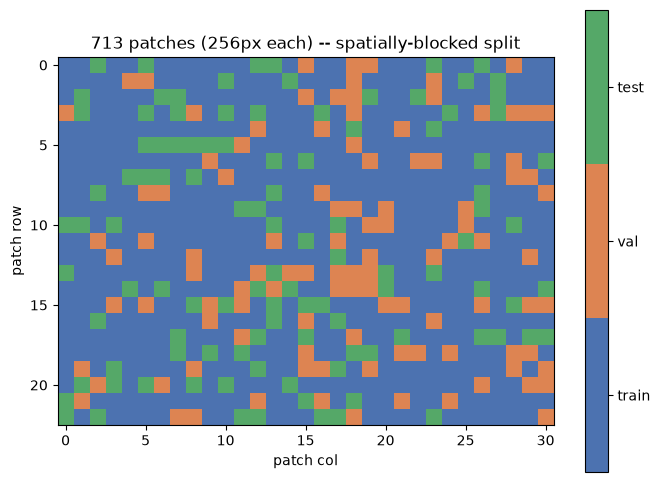

In [5]:
from matplotlib.colors import ListedColormap

n_rows = max(p['row'] for p in patches) + 1
n_cols = max(p['col'] for p in patches) + 1
split_codes = {'train': 0, 'val': 1, 'test': 2}
grid = np.zeros((n_rows, n_cols), dtype=int)
for p, s in zip(patches, patch_split):
    grid[p['row'], p['col']] = split_codes[s]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(grid, cmap=ListedColormap(['#4c72b0', '#dd8452', '#55a868']), vmin=-0.5, vmax=2.5)
cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(['train', 'val', 'test'])
ax.set_title(f'{len(patches)} patches ({PATCH_SIZE}px each) -- spatially-blocked split')
ax.set_xlabel('patch col')
ax.set_ylabel('patch row')
plt.show()

## Task 1: pixel-level channel-to-channel image translation

Given one or more fluorescence channel *images*, predict another channel's image
directly in pixel space, using a small U-Net trained on the patches above. Naming
mirrors `intrinsic.ipynb`/`extrinsic.ipynb`: `Hoechst_to_X` (the nuclear/morphology-
proxy channel predicting a marker -- the pixel analog of `morph_to_if`) and
`other_if_to_X` (the other two marker channels predicting the third -- the pixel
analog of the leave-one-out block).

Only pixels inside a real, kept cell count toward training and evaluation --
`cell_mask` (built from the Cellpose label mask, restricted to the same cells kept in
`cell_df`) masks out background fluorescence, so it never counts as "immunofluorescence
signal." The U-Net still sees the *whole* patch as input (background included, for
spatial context), but the loss and $R^2$ are computed over in-cell pixels only.

In [ ]:
from torch.utils.data import DataLoader
from tools.morphology import (
    UNet,
    PatchImageDataset,
    fit_channel_stats,
    train_cnn,
    pixel_r2,
    predict_patch,
    plot_loss_curves,
    plot_experiment_comparison,
)

# Edit this to change which channel(s) predict which -- any subset of channel_names
# works on either side. Comment out an entry to skip running it.
PIXEL_EXPERIMENTS = {
    'other_if_to_HAND1': dict(input_channels=['BMP4', 'T'],   target_channel='HAND1'),
    'other_if_to_BMP4':  dict(input_channels=['HAND1', 'T'],  target_channel='BMP4'),
    'other_if_to_T':     dict(input_channels=['HAND1', 'BMP4'], target_channel='T'),
}

In [7]:
def run_pixel_experiment(
    name, input_channels, target_channel,
    base_channels=16, depth=3, dropout=0.0,
    epochs=60, lr=1e-3, batch_size=16, patience=8,
    device='cpu',
):
    """Full pipeline for one (input_channels -> target_channel) pixel-translation
    config: fit channel stats on TRAIN patches only, train a small U-Net, evaluate
    pixel-wise R^2 on the held-out TEST patches, and show one predicted-vs-actual
    test patch side by side."""
    print(f'\n=== {name}: {input_channels} -> {target_channel} ===')

    input_idx = [channel_names.index(c) for c in input_channels]
    target_idx = [channel_names.index(target_channel)]
    x_mean, x_std = fit_channel_stats(out, cell_mask, train_patches, input_idx)
    y_mean, y_std = fit_channel_stats(out, cell_mask, train_patches, target_idx)

    train_ds = PatchImageDataset(out, cell_mask, train_patches, input_channels, target_channel, channel_names, x_mean, x_std, y_mean, y_std)
    val_ds   = PatchImageDataset(out, cell_mask, val_patches,   input_channels, target_channel, channel_names, x_mean, x_std, y_mean, y_std)
    test_ds  = PatchImageDataset(out, cell_mask, test_patches,  input_channels, target_channel, channel_names, x_mean, x_std, y_mean, y_std)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size)
    test_loader  = DataLoader(test_ds, batch_size=batch_size)

    model = UNet(in_channels=len(input_channels), out_channels=1, base_channels=base_channels, depth=depth)
    history = train_cnn(model, train_loader, val_loader, epochs=epochs, lr=lr, patience=patience, device=device, desc=name)
    plot_loss_curves({name: history}, title=name)
    plt.show()

    r2 = pixel_r2(model, test_loader, device=device)
    r2_df = pd.DataFrame({'R2': {target_channel: r2}})
    r2_df.index.name = 'feature'
    print(f'test pixel R^2: {r2:.3f}')

    x_in, y_true, y_pred, _ = predict_patch(model, test_ds, 0, device=device)
    fig, axes = plt.subplots(1, len(input_channels) + 2, figsize=(4 * (len(input_channels) + 2), 4))
    for i, c in enumerate(input_channels):
        axes[i].imshow(x_in[i], cmap='gray')
        axes[i].set_title(f'input: {c}')
        axes[i].axis('off')
    axes[-2].imshow(y_true[0], cmap='magma')
    axes[-2].set_title(f'true: {target_channel}')
    axes[-2].axis('off')
    axes[-1].imshow(y_pred[0], cmap='magma')
    axes[-1].set_title(f'predicted: {target_channel}')
    axes[-1].axis('off')
    fig.suptitle(f'{name}, test patch 0 (standardized units)')
    plt.show()

    return dict(model=model, history=history, r2=r2_df)


=== other_if_to_HAND1: ['BMP4', 'T'] -> HAND1 ===


other_if_to_HAND1:   0%|          | 0/60 [00:00<?, ?it/s]

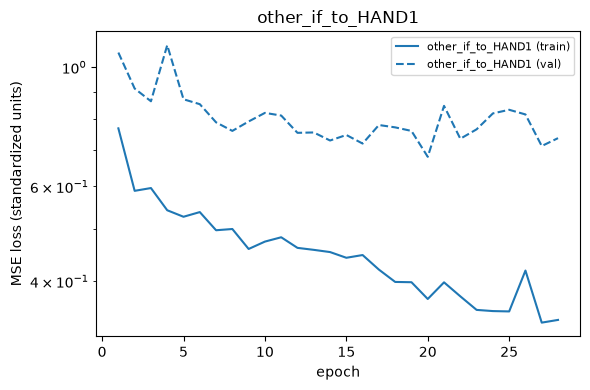

test pixel R^2: 0.599


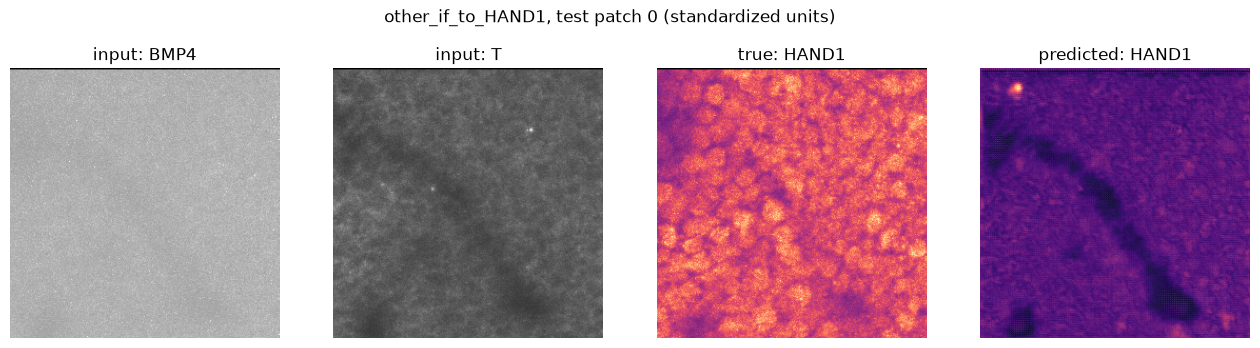


=== other_if_to_BMP4: ['HAND1', 'T'] -> BMP4 ===


other_if_to_BMP4:   0%|          | 0/60 [00:00<?, ?it/s]

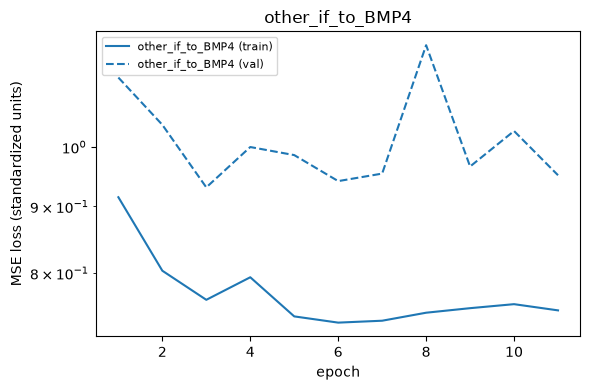

test pixel R^2: 0.325


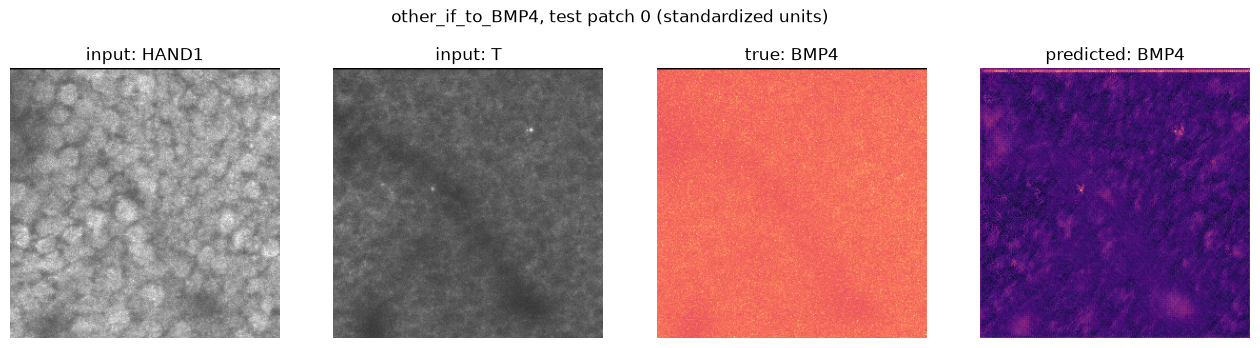


=== other_if_to_T: ['HAND1', 'BMP4'] -> T ===


other_if_to_T:   0%|          | 0/60 [00:00<?, ?it/s]

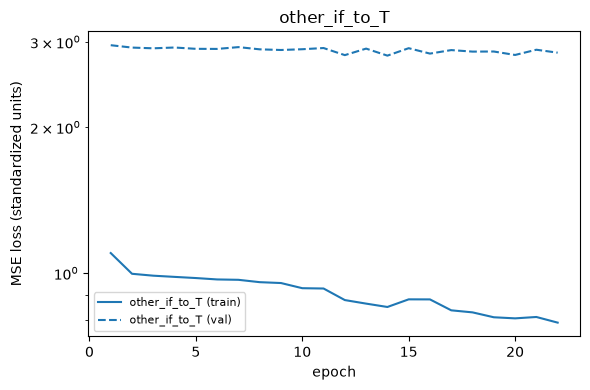

test pixel R^2: 0.150


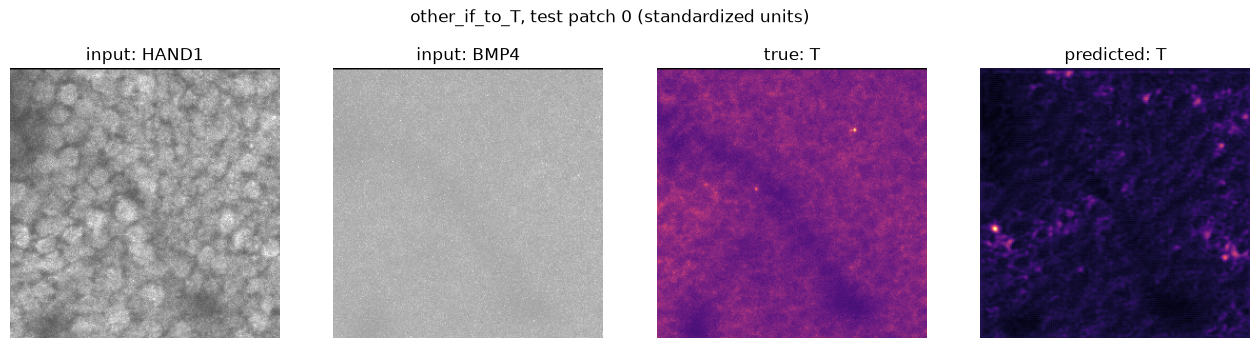

In [8]:
pixel_results = {
    name: run_pixel_experiment(name, cfg['input_channels'], cfg['target_channel'], device='mps')
    for name, cfg in PIXEL_EXPERIMENTS.items()
}

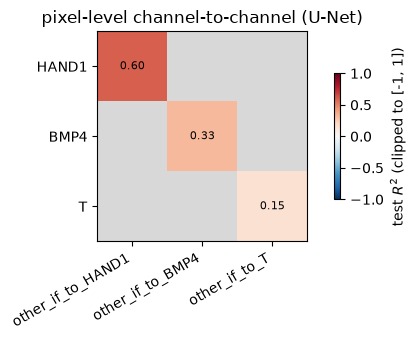

experiment,other_if_to_HAND1,other_if_to_BMP4,other_if_to_T
target,,,
HAND1,0.598502,NaN,NaN
BMP4,NaN,0.325035,NaN
T,NaN,NaN,0.150249


In [ ]:
pixel_y_cols = {name: [cfg['target_channel']] for name, cfg in PIXEL_EXPERIMENTS.items()}
pixel_summary = plot_experiment_comparison(pixel_results, pixel_y_cols, title='pixel-level channel-to-channel (U-Net)')
display(pixel_summary)

## Task 2: patch-graph morphology <-> immunofluorescence

Given a cell's own morphology *and* its spatial position/neighbors within a patch,
predict its immunofluorescence (and vice versa) -- the same mapping as
`intrinsic.ipynb`, but now letting the model use graph/spatial structure that
`intrinsic.ipynb` deliberately leaves out, evaluated with the same spatially-blocked
split as Task 1 (entire patches held out) rather than a random per-cell split.

Unlike `extrinsic.ipynb`'s `NeighborFeaturePredictor` (which deliberately excludes a
cell's own features to isolate a pure non-cell-autonomous signal), this uses
`CellGNNWithHead` (self + neighbor mixing) since the question here is the *combined*
predictive power of a cell's own morphology plus its spatial context -- not neighbors
in isolation.

In [ ]:
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GeoDataLoader

from tools.morphology import (
    MORPHOLOGY_COLS,
    marker_cols,
    zero_out_negative_if,
    knn_edge_index,
    CellGNNWithHead,
    leave_one_out_configs,
    train_patch_gnn,
    predict_patch_gnn,
    r2_table,
    plot_pred_vs_actual,
)

EXCLUDE_HOECHST = True
# If True, sets `{marker}_mean` to 0 for every cell where `{marker}+` is False --
# treats IF-negative as true zero signal rather than whatever background/baseline
# intensity the mean happened to measure. No-op on the saved CSV -- this only ever
# alters the in-memory `cell_df` here. Only affects Task 2 (Task 1 works directly on
# `out`'s raw pixels, not cell_df's mean columns).
ZERO_OUT_NEGATIVE_IF = False

morphology_cols = MORPHOLOGY_COLS
if_cols = marker_cols(cell_df, 'mean')
if EXCLUDE_HOECHST:
    if_cols = [c for c in if_cols if c != 'Hoechst_mean']

cell_df = zero_out_negative_if(cell_df, if_cols, zero_out=ZERO_OUT_NEGATIVE_IF)

MIN_CELLS_PER_PATCH = 5  # skip near-empty patches (e.g. sitting over a gap in the tissue)

# scalers fit on TRAIN patches' cells only (same discipline as intrinsic.ipynb/extrinsic.ipynb)
train_cells = pd.concat([crop_cell_df(cell_df, p) for p in train_patches], axis=0)

print(f'{len(morphology_cols)} morphology features:', morphology_cols)
print(f'{len(if_cols)} immunofluorescence features:', if_cols)

In [11]:
def build_patch_graph(sub, x_cols, y_cols, mean_x, std_x, mean_y, std_y, k=6):
    """One small graph from one patch's cells: x = own morphology/IF (standardized),
    edges = k-NN on centroid (this patch's cells only), y = own target (standardized)."""
    centroids = np.ascontiguousarray(sub[['centroid_y', 'centroid_x']].to_numpy(dtype=np.float32))
    x = (sub[x_cols].to_numpy(dtype=np.float32) - mean_x) / std_x
    y = (sub[y_cols].to_numpy(dtype=np.float32) - mean_y) / std_y
    edge_index, _ = knn_edge_index(centroids, k=k)
    return Data(x=torch.from_numpy(x), edge_index=torch.from_numpy(edge_index), y=torch.from_numpy(y))


def run_patch_graph_experiment(
    name, x_cols, y_cols, k=6,
    hidden_channels=64, embedding_dim=32, num_layers=2, conv_type='sage', dropout=0.1,
    epochs=100, lr=1e-3, patience=12, batch_size=16,
):
    """Full pipeline for one (x_cols -> y_cols) patch-graph configuration: fit
    scalers on TRAIN patches' cells only, build one small graph per patch, train a
    CellGNNWithHead across all patch-graphs, and evaluate on held-out TEST patches
    (original units)."""
    print(f'\n=== {name}: {x_cols} -> {y_cols} ===')

    mean_x = train_cells[x_cols].to_numpy(dtype=np.float32).mean(axis=0)
    std_x = train_cells[x_cols].to_numpy(dtype=np.float32).std(axis=0)
    std_x = np.where(std_x < 1e-8, 1.0, std_x)
    mean_y = train_cells[y_cols].to_numpy(dtype=np.float32).mean(axis=0)
    std_y = train_cells[y_cols].to_numpy(dtype=np.float32).std(axis=0)
    std_y = np.where(std_y < 1e-8, 1.0, std_y)

    def build_graphs(patch_list):
        graphs = []
        for p in patch_list:
            sub = crop_cell_df(cell_df, p)
            if len(sub) < MIN_CELLS_PER_PATCH:
                continue
            graphs.append(build_patch_graph(sub, x_cols, y_cols, mean_x, std_x, mean_y, std_y, k=k))
        return graphs

    train_graphs = build_graphs(train_patches)
    val_graphs = build_graphs(val_patches)
    test_graphs = build_graphs(test_patches)
    print(f'{len(train_graphs)} train / {len(val_graphs)} val / {len(test_graphs)} test patch-graphs')

    train_loader = GeoDataLoader(train_graphs, batch_size=batch_size, shuffle=True)
    val_loader = GeoDataLoader(val_graphs, batch_size=batch_size)
    test_loader = GeoDataLoader(test_graphs, batch_size=batch_size)

    model = CellGNNWithHead(
        in_channels=len(x_cols), num_outputs=len(y_cols),
        hidden_channels=hidden_channels, embedding_dim=embedding_dim,
        num_layers=num_layers, conv_type=conv_type, dropout=dropout,
    )
    history = train_patch_gnn(model, train_loader, val_loader, epochs=epochs, lr=lr, patience=patience, desc=name)
    plot_loss_curves({name: history}, title=name)
    plt.show()

    pred_scaled, true_scaled = predict_patch_gnn(model, test_loader)
    pred_df = pd.DataFrame(pred_scaled * std_y + mean_y, columns=y_cols)
    true_df = pd.DataFrame(true_scaled * std_y + mean_y, columns=y_cols)
    r2 = r2_table(true_df, pred_df)
    display(r2)
    plot_pred_vs_actual(true_df, pred_df, title=f'{name}, test set')
    plt.show()

    return dict(model=model, history=history, r2=r2)

In [18]:
# Edit this to change what predicts what -- same convention as intrinsic.ipynb. Any
# extra kwarg (e.g. hidden_channels, num_layers, conv_type) gets forwarded to
# run_patch_graph_experiment.

GRAPH_EXPERIMENTS = {
    'morph_to_if': dict(x_cols=morphology_cols, y_cols=if_cols),
    'if_to_morph': dict(x_cols=if_cols, y_cols=morphology_cols),
    **leave_one_out_configs(if_cols, prefix='other_if_to'),
    'HAND1_to_if':    dict(x_cols=['HAND1_mean'],    y_cols=if_cols),
    'BMP4_to_if':     dict(x_cols=['BMP4_mean'],     y_cols=if_cols),
    'T_to_if':        dict(x_cols=['T_mean'],        y_cols=if_cols),
    'HAND1_to_morph': dict(x_cols=['HAND1_mean'],    y_cols=morphology_cols),
    'BMP4_to_morph':  dict(x_cols=['BMP4_mean'],     y_cols=morphology_cols),
    'T_to_morph':     dict(x_cols=['T_mean'],        y_cols=morphology_cols),
}

# GRAPH_EXPERIMENTS = {
#     'morph_to_if':    dict(x_cols=morphology_cols,   y_cols=if_cols),
#     'if_to_morph':    dict(x_cols=if_cols,           y_cols=morphology_cols),
#     'morph_to_morph': dict(x_cols=morphology_cols,   y_cols=morphology_cols),
#     'if_to_if':       dict(x_cols=if_cols,           y_cols=if_cols),
#     'HAND1_to_if':    dict(x_cols=['HAND1_mean'],    y_cols=if_cols),
#     'BMP4_to_if':     dict(x_cols=['BMP4_mean'],     y_cols=if_cols),
#     'T_to_if':        dict(x_cols=['T_mean'],        y_cols=if_cols),
#     'HAND1_to_morph': dict(x_cols=['HAND1_mean'],    y_cols=morphology_cols),
#     'BMP4_to_morph':  dict(x_cols=['BMP4_mean'],     y_cols=morphology_cols),
#     'T_to_morph':     dict(x_cols=['T_mean'],        y_cols=morphology_cols),
#     # leave-one-out within neighbors' IF markers -- parallel to intrinsic.ipynb's
#     # other_if_to_* block, but predicting the CENTER cell's marker from its
#     # NEIGHBORS' other markers (excluding the neighbors' value of that same marker):
#     **leave_one_out_configs(if_cols, prefix='other_if_to', x_key='x_cols', y_key='y_cols'),
# }


=== morph_to_if: ['area', 'perimeter_crofton', 'circularity', 'eccentricity'] -> ['HAND1_mean', 'BMP4_mean', 'T_mean'] ===
499 train / 107 val / 107 test patch-graphs


morph_to_if:   0%|          | 0/100 [00:00<?, ?it/s]

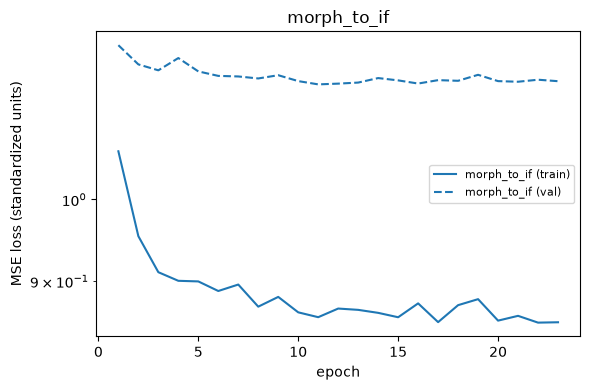

,R2,MAE
feature,,
HAND1_mean,0.275515,62.999081
BMP4_mean,0.091184,50.541851
T_mean,0.007314,16.070383


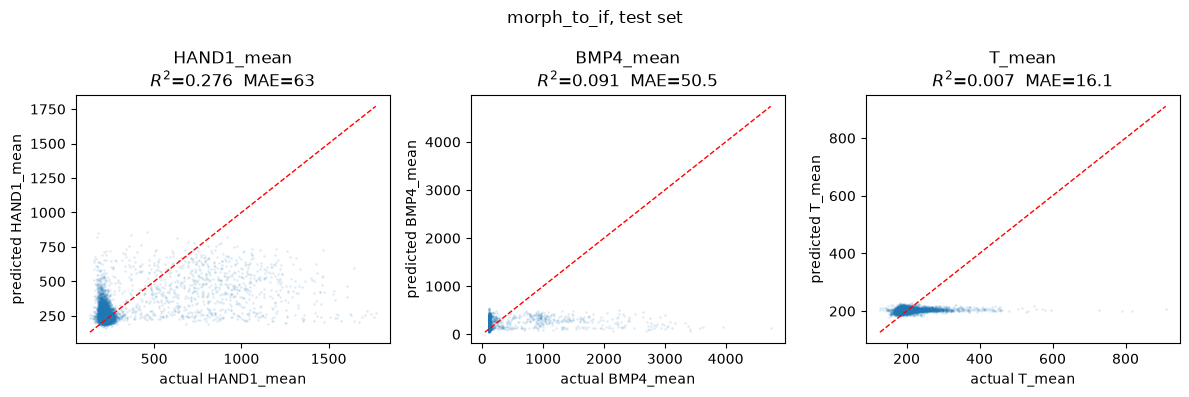


=== if_to_morph: ['HAND1_mean', 'BMP4_mean', 'T_mean'] -> ['area', 'perimeter_crofton', 'circularity', 'eccentricity'] ===
499 train / 107 val / 107 test patch-graphs


if_to_morph:   0%|          | 0/100 [00:00<?, ?it/s]

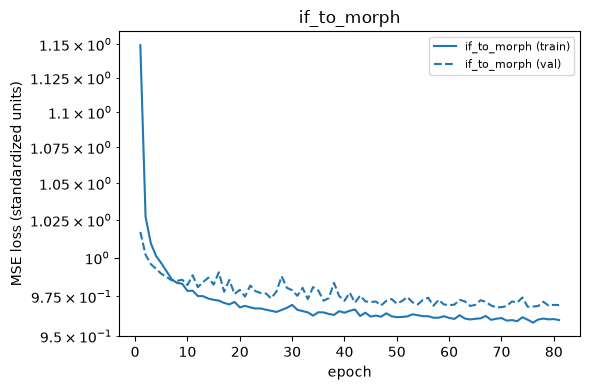

,R2,MAE
feature,,
area,0.058989,86.461319
perimeter_crofton,0.044041,8.832665
circularity,0.039362,0.050464
eccentricity,0.001078,0.112304


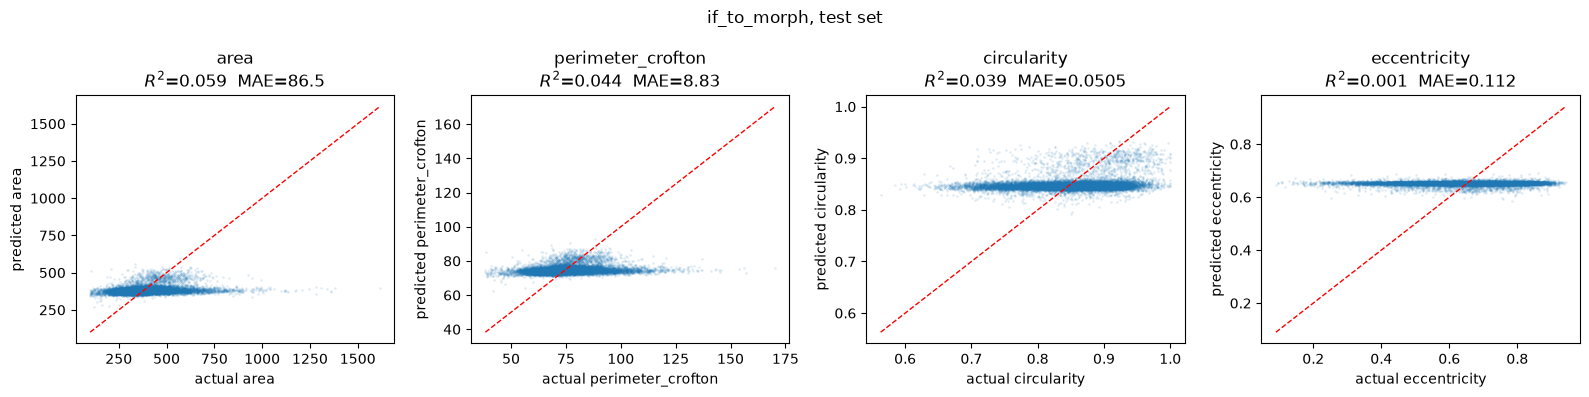


=== other_if_to_HAND1_mean: ['BMP4_mean', 'T_mean'] -> ['HAND1_mean'] ===
499 train / 107 val / 107 test patch-graphs


other_if_to_HAND1_mean:   0%|          | 0/100 [00:00<?, ?it/s]

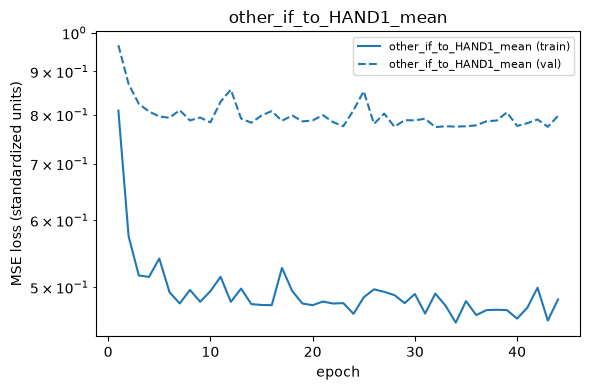

,R2,MAE
feature,,
HAND1_mean,0.624978,38.065308


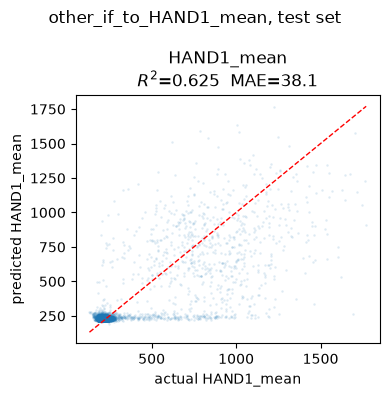


=== other_if_to_BMP4_mean: ['HAND1_mean', 'T_mean'] -> ['BMP4_mean'] ===
499 train / 107 val / 107 test patch-graphs


other_if_to_BMP4_mean:   0%|          | 0/100 [00:00<?, ?it/s]

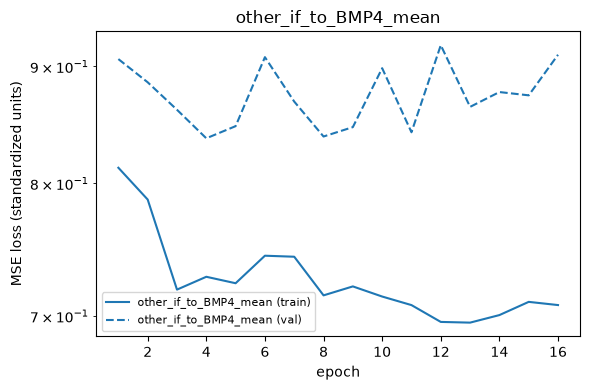

,R2,MAE
feature,,
BMP4_mean,0.383137,35.007706


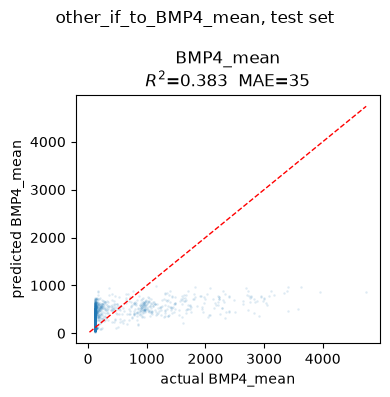


=== other_if_to_T_mean: ['HAND1_mean', 'BMP4_mean'] -> ['T_mean'] ===
499 train / 107 val / 107 test patch-graphs


other_if_to_T_mean:   0%|          | 0/100 [00:00<?, ?it/s]

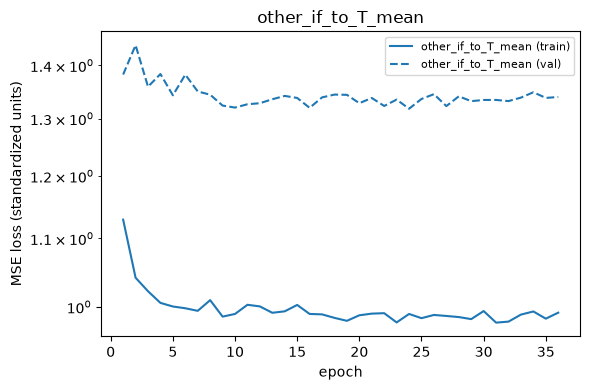

,R2,MAE
feature,,
T_mean,0.015489,15.884323


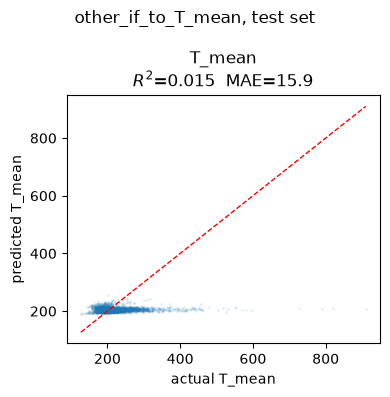


=== HAND1_to_if: ['HAND1_mean'] -> ['HAND1_mean', 'BMP4_mean', 'T_mean'] ===
499 train / 107 val / 107 test patch-graphs


HAND1_to_if:   0%|          | 0/100 [00:00<?, ?it/s]

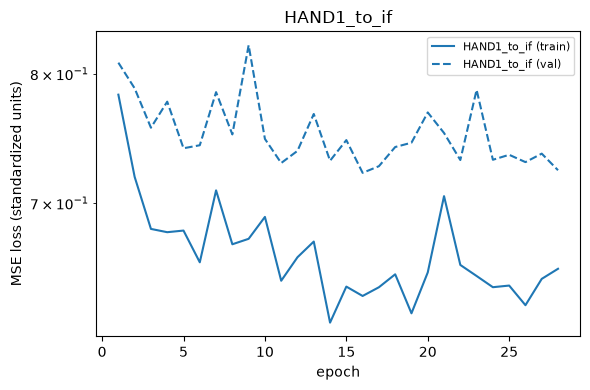

,R2,MAE
feature,,
HAND1_mean,0.995582,6.304915
BMP4_mean,0.386435,35.755478
T_mean,-0.000573,16.367149


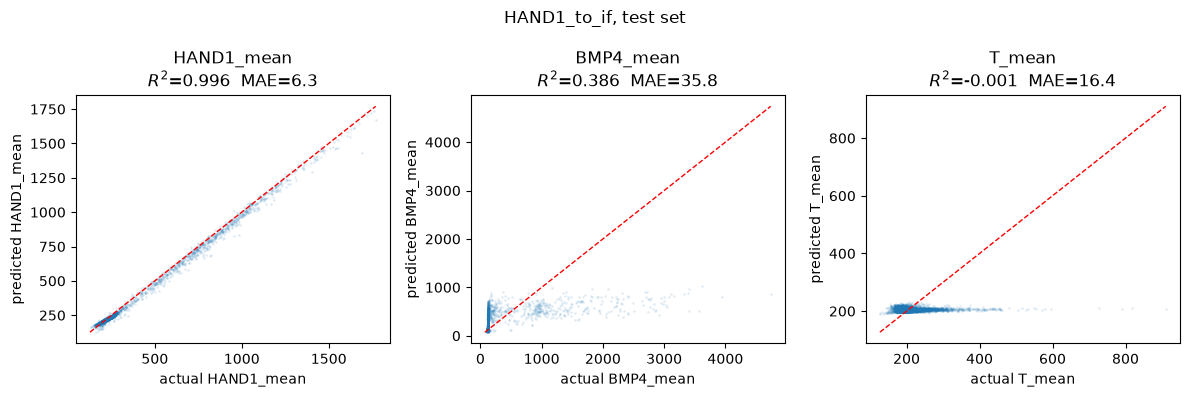


=== BMP4_to_if: ['BMP4_mean'] -> ['HAND1_mean', 'BMP4_mean', 'T_mean'] ===
499 train / 107 val / 107 test patch-graphs


BMP4_to_if:   0%|          | 0/100 [00:00<?, ?it/s]

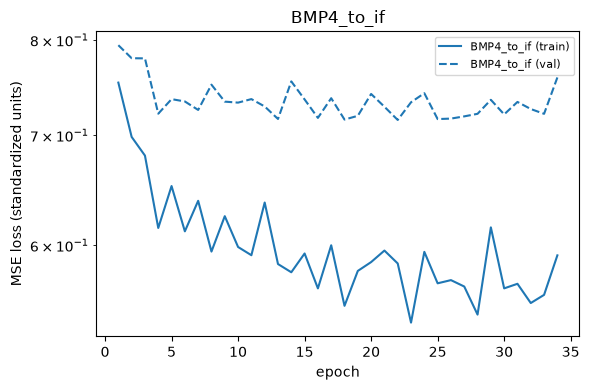

,R2,MAE
feature,,
HAND1_mean,0.611180,37.329697
BMP4_mean,0.978393,5.579106
T_mean,-0.022863,17.042889


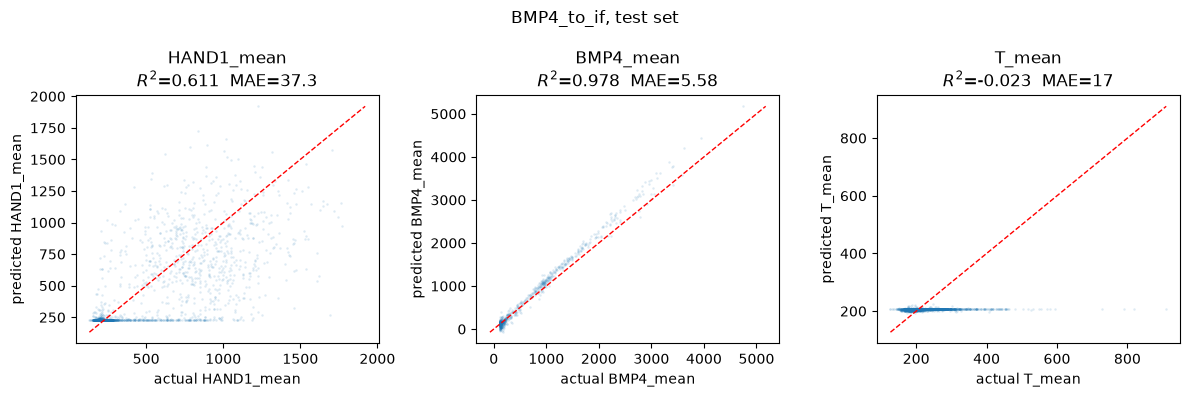


=== T_to_if: ['T_mean'] -> ['HAND1_mean', 'BMP4_mean', 'T_mean'] ===
499 train / 107 val / 107 test patch-graphs


T_to_if:   0%|          | 0/100 [00:00<?, ?it/s]

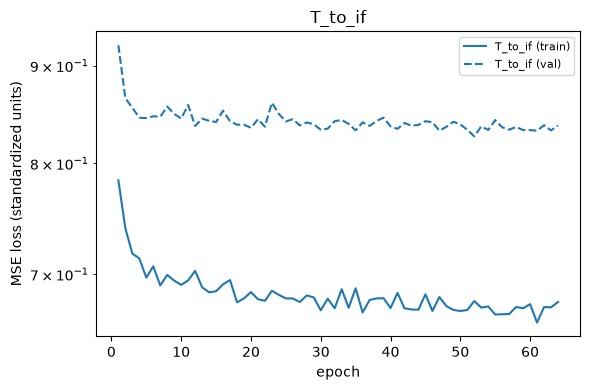

,R2,MAE
feature,,
HAND1_mean,0.047754,68.308624
BMP4_mean,0.022293,52.518047
T_mean,0.998375,0.827995


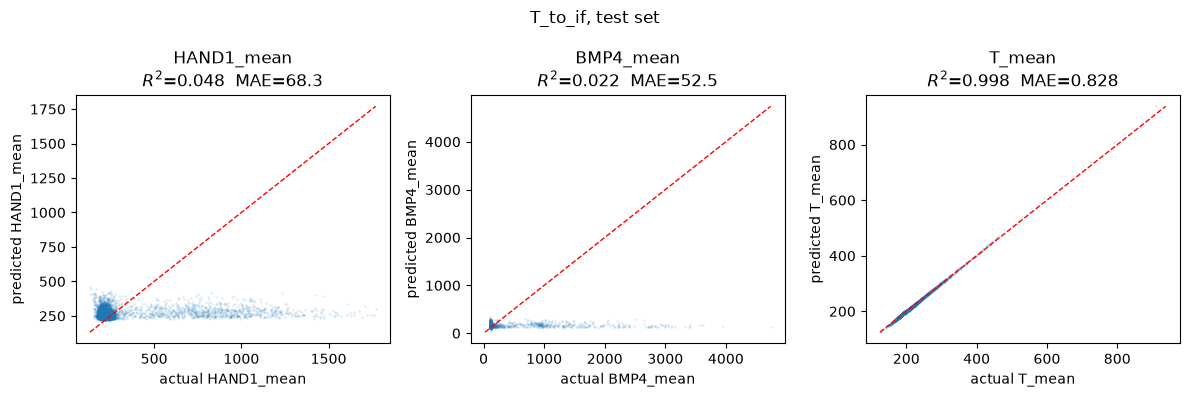


=== HAND1_to_morph: ['HAND1_mean'] -> ['area', 'perimeter_crofton', 'circularity', 'eccentricity'] ===
499 train / 107 val / 107 test patch-graphs


HAND1_to_morph:   0%|          | 0/100 [00:00<?, ?it/s]

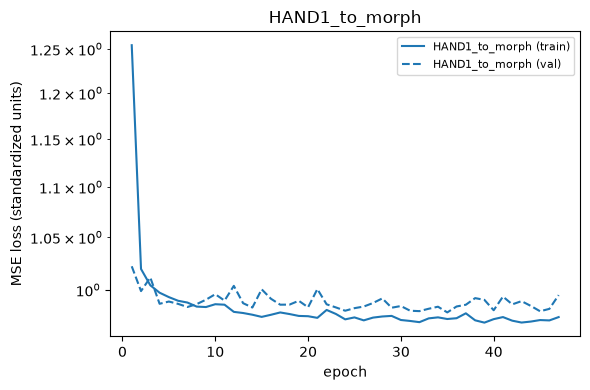

,R2,MAE
feature,,
area,0.048131,87.640289
perimeter_crofton,0.036995,8.857677
circularity,0.025267,0.050916
eccentricity,0.000639,0.112579


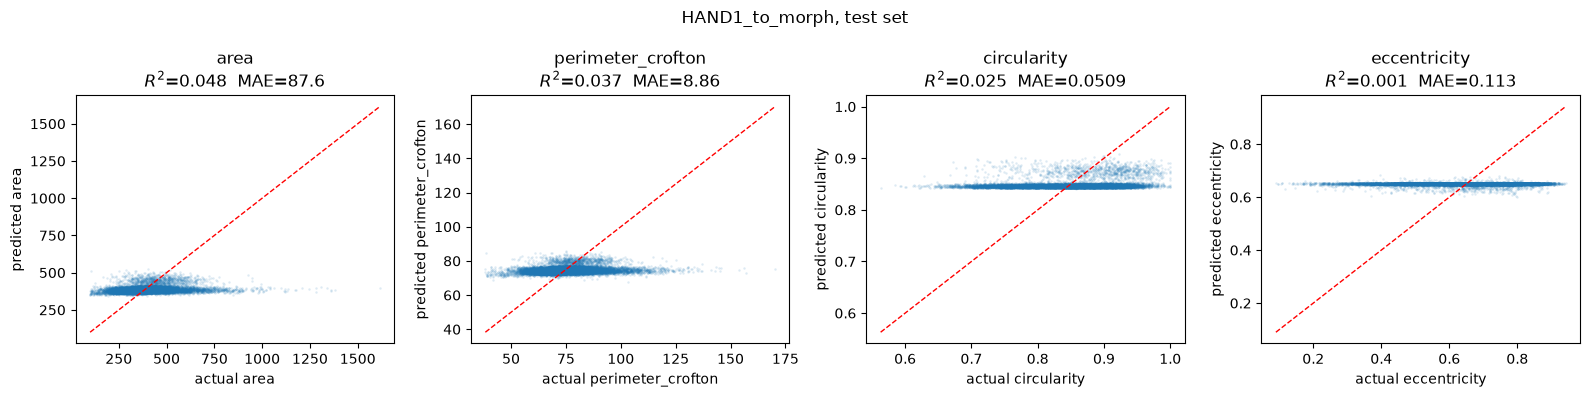


=== BMP4_to_morph: ['BMP4_mean'] -> ['area', 'perimeter_crofton', 'circularity', 'eccentricity'] ===
499 train / 107 val / 107 test patch-graphs


BMP4_to_morph:   0%|          | 0/100 [00:00<?, ?it/s]

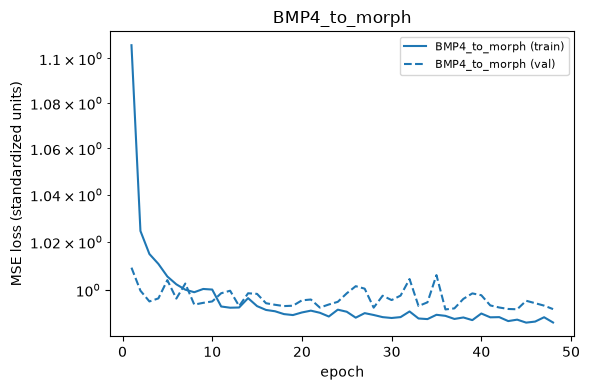

,R2,MAE
feature,,
area,0.011449,90.559883
perimeter_crofton,0.005342,9.156993
circularity,0.013400,0.050893
eccentricity,-0.002251,0.112755


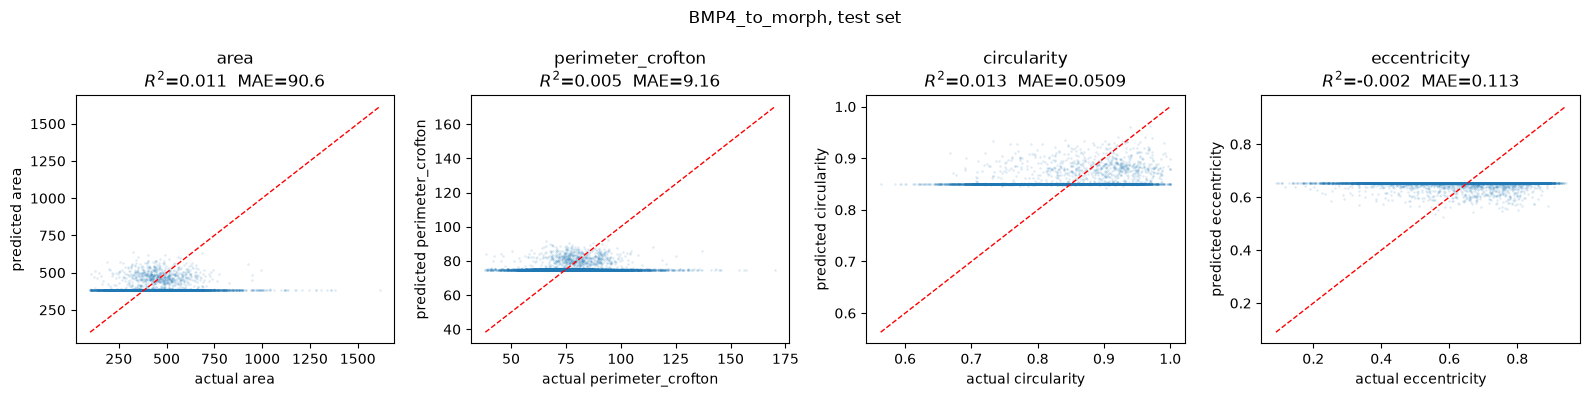


=== T_to_morph: ['T_mean'] -> ['area', 'perimeter_crofton', 'circularity', 'eccentricity'] ===
499 train / 107 val / 107 test patch-graphs


T_to_morph:   0%|          | 0/100 [00:00<?, ?it/s]

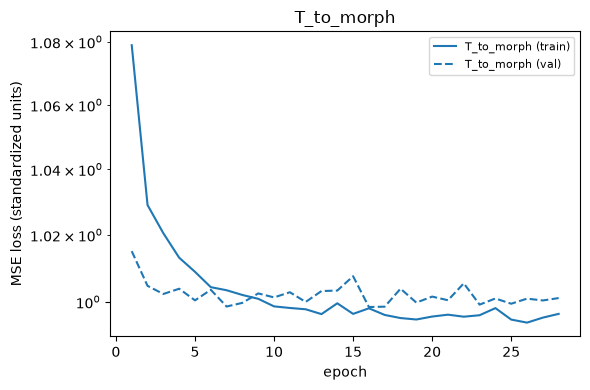

,R2,MAE
feature,,
area,0.012024,90.671738
perimeter_crofton,0.009282,9.138405
circularity,0.007973,0.051132
eccentricity,-0.000547,0.112742


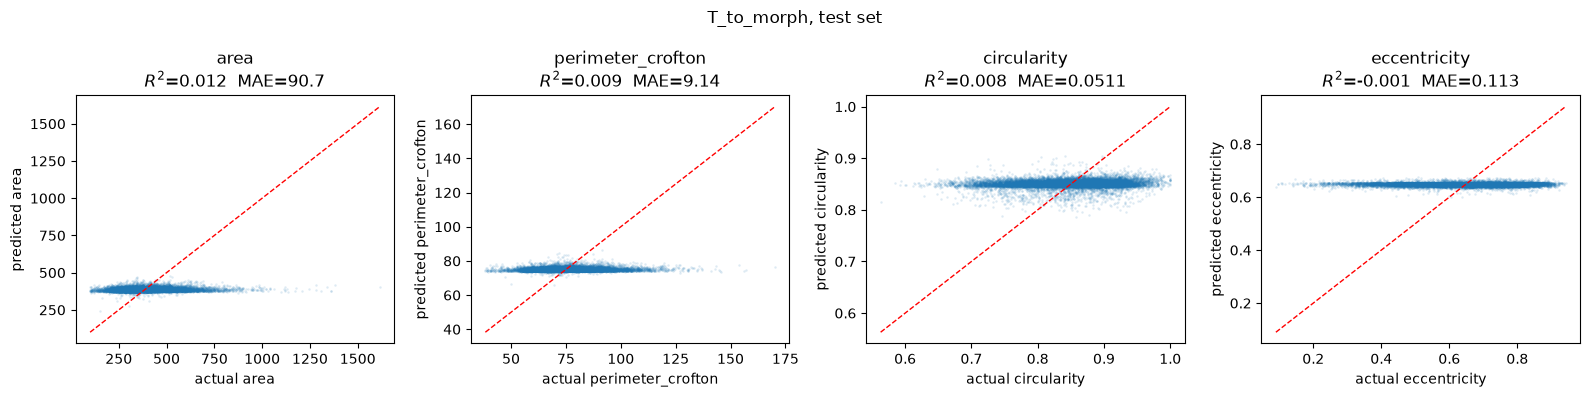

In [19]:
patch_graph_results = {
    name: run_patch_graph_experiment(
        name, cfg['x_cols'], cfg['y_cols'],
        **{k: v for k, v in cfg.items() if k not in ('x_cols', 'y_cols')},
    )
    for name, cfg in GRAPH_EXPERIMENTS.items()
}

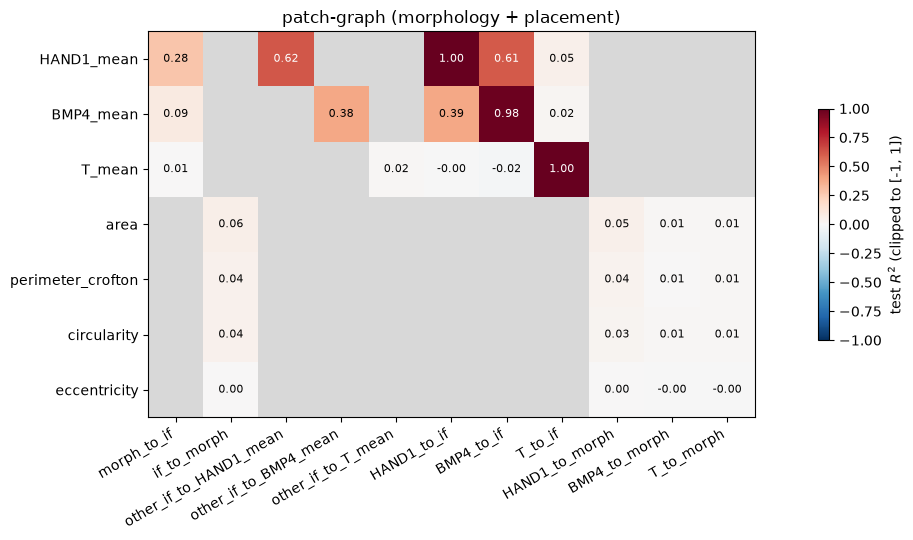

experiment,morph_to_if,if_to_morph,other_if_to_HAND1_mean,other_if_to_BMP4_mean,other_if_to_T_mean,HAND1_to_if,BMP4_to_if,T_to_if,HAND1_to_morph,BMP4_to_morph,T_to_morph
target,,,,,,,,,,,
HAND1_mean,0.275515,NaN,0.624978,NaN,NaN,0.995582,0.611180,0.047754,NaN,NaN,NaN
BMP4_mean,0.091184,NaN,NaN,0.383137,NaN,0.386435,0.978393,0.022293,NaN,NaN,NaN
T_mean,0.007314,NaN,NaN,NaN,0.015489,-0.000573,-0.022863,0.998375,NaN,NaN,NaN
area,NaN,0.058989,NaN,NaN,NaN,NaN,NaN,NaN,0.048131,0.011449,0.012024
perimeter_crofton,NaN,0.044041,NaN,NaN,NaN,NaN,NaN,NaN,0.036995,0.005342,0.009282
circularity,NaN,0.039362,NaN,NaN,NaN,NaN,NaN,NaN,0.025267,0.013400,0.007973
eccentricity,NaN,0.001078,NaN,NaN,NaN,NaN,NaN,NaN,0.000639,-0.002251,-0.000547


In [20]:
graph_y_cols = {name: cfg['y_cols'] for name, cfg in GRAPH_EXPERIMENTS.items()}
graph_summary = plot_experiment_comparison(patch_graph_results, graph_y_cols, title='patch-graph (morphology + placement)')
display(graph_summary)

## Next steps

- **Compare against `intrinsic.ipynb` and `extrinsic.ipynb`** for the same targets: if
  Task 2's patch-graph $R^2$ sits close to `intrinsic.ipynb`'s despite the stricter
  spatially-blocked split, that split isn't costing much accuracy -- a good sign the
  earlier random per-cell splits weren't inflated by train/test leakage between
  adjacent cells. If patch-graph clearly beats `extrinsic.ipynb`'s neighbor-only
  numbers, that's evidence a cell's own morphology still carries most of the signal,
  with spatial context adding only a little on top.
- **Pixel-level (Task 1) vs. per-cell (Task 2) $R^2$ aren't directly comparable
  numbers** -- one is over raw pixels, the other over per-cell mean intensities --
  but the *qualitative pattern* (which channel/marker pairs predict each other well)
  should agree across both if per-cell aggregation is capturing the real signal.
  Worth checking directly.
- **`PATCH_SIZE`, `k`, `MIN_CELLS_PER_PATCH`** are all worth sweeping: smaller patches
  give more samples but noisier/smaller graphs (and eventually too few cells for a
  sensible k-NN graph); larger patches trade the other way.
- Only one FOV/image is used here. Once more are segmented, patches naturally extend
  across images (each patch's cells already come from one `cell_df`/image; a
  multi-image version just concatenates more patches from more images), giving
  genuinely out-of-image generalization on top of out-of-region.